In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
# CSV dosyasından deneyim-maaş verisini okuyoruz ve ilk 5 satırı gösteriyoruz
data = pd.read_csv("/Users/berkecelik/Downloads/tecrube_maas.csv")
data.head()

,Tecrübe,Maaş
0,1.1,3934
1,1.3,4620
2,1.5,3773
3,2.0,4352
4,2.2,3989


In [51]:
# Bağımsız değişkeni (x: deneyim, sklearn için 2D reshape edilmiş)
# ve bağımlı değişkeni (y: maaş) ayırıyoruz
x = data.iloc[:,0].values.reshape(-1,1)
y = data.iloc[:,1]

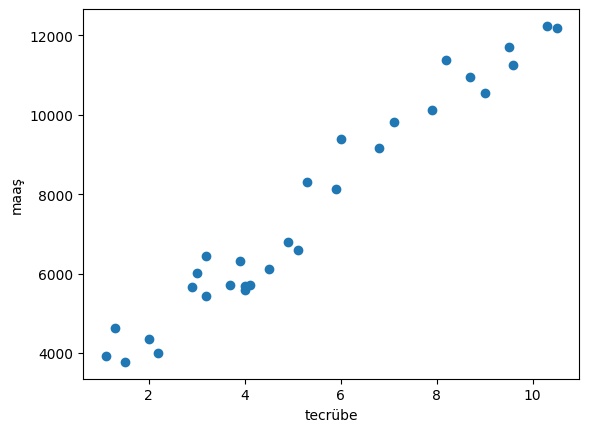

In [52]:
# Deneyim ile maaş arasındaki ilişkiyi nokta grafiği (scatter plot) olarak çiziyoruz
plt.scatter(x,y)
plt.xlabel("tecrübe")
plt.ylabel("maaş")
plt.show()

In [53]:
# Veriyi %70 eğitim (train) ve %30 test (test) olarak ayırıyoruz
# (random_state ile bölünme her çalıştırmada aynı olacak şekilde sabitleniyor)
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.3, random_state = 33)

In [54]:
# sklearn'den LinearRegression sınıfını içe aktarıp bir model örneği oluşturuyoruz
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [55]:
# Doğrusal regresyon modelini eğitim verisiyle (xtrain, ytrain) eğitiyoruz
lr.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[965.39]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2501
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[12.21]


In [56]:
# Eğitilen modelle test verisi (xtest) üzerinde tahmin yapıyor
# ve tahmin edilen değerleri (yhead) görüntülüyoruz
yhead = lr.predict(xtest)
yhead

array([12637.83663411,  7424.75461917,  7617.83173083,  5300.90639086,
        4625.13650003,  5590.52205835,  7231.6775075 , 11672.45107578,
       11768.98963162])

In [57]:
# Deneyimi 2 yıl olan biri için modelin tahmin ettiği maaşı hesaplıyoruz
lr.predict([[2]])

array([4432.05938837])

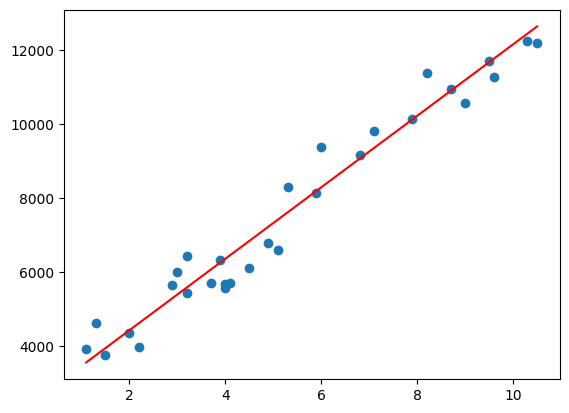

In [58]:
# Gerçek verileri nokta grafiği olarak, modelin öğrendiği doğrusal ilişkiyi
# ise kırmızı çizgi olarak aynı grafik üzerinde gösteriyoruz
plt.scatter(x,y)
plt.plot(x, lr.predict(x), color = "red")